In [1]:
import warnings
from typing import List, Literal, Optional, Tuple

import moscot as mt
import moscot.plotting as mtp
import ot
import tqdm
from moscot.problems.time import LineageProblem, TemporalProblem

import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import euclidean_distances

import matplotlib.pyplot as plt
import pycea as py

import scanpy as sc
from anndata import AnnData
import treedata as td

warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", FutureWarning)

In [3]:
pwd

'/project/imoskowitz/yubin'

In [4]:
cd Lineage_Tree_Construction/

/project/imoskowitz/yubin/Lineage_Tree_Construction


In [5]:
from Moslin.utility import compute_w2, get_cost, compute_errors

Early run, only **first replicate** is used. Since there are also multiple clones in the replicate, I will take the clone with the biggest lineage tree and as a result should probably subset the data before we concat. 
TODO: Figure out why there are multiple clones. Why the nodes in the tree and the clone cell count do not match up 
TODO: Create cost matrix for each time point, and the cost matrix 
TODO: Use Gene Expression for cost matrix across time points 

#### Data loading

In [147]:
from pathlib import Path
basePath = "/project/imoskowitz/yubin/Lineage_Tree_Construction/"
output_data = basePath + "output_data/"
output_plot = basePath + "output_plot/"

In [56]:
Lineage_data = Path("/project/imoskowitz/kdreyer/public_datasets/005_Colgan2026/")
tdatas = {}
for file_path in Lineage_data.glob("*R1.h5td"): # Taking only the first replicate

    # tdatas[file_path.stem] = td.read_h5td(file_path)

    # For testing, extract only timepoint lower than E9.0
    # Extract stage from filename (e.g., "E8.5-R1" from "E8.5-R1-C1.h5td")
    stem = file_path.stem
    stage = stem.split("-")[0]  # Extract "E8.5", "E9.0", etc.
    
    # Parse the stage to compare versions (e.g., E8.5, E9.0)
    stage_num = float(stage[1:])  # Remove 'E' and convert to float
    
    # Exclude E9.0 and above
    if stage_num < 9.0:
        tdatas[stem] = td.read_h5td(file_path)

In [57]:
for tdata in tdatas.values():
    print(tdata)

TreeData object with n_obs × n_vars = 23392 × 78258
    obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'tree'
    var: 'gene_ids', 'mito', 'chromosome'
    obsm: 'X_scvi', 'X_umap', 'characters'
    obst: 'E8.5-R1-C1', 'E8.5-R1-C2', 'E8.5-R1-C3', 'E8.5-R1-C4'
TreeData object with n_obs × n_vars = 1342 × 78258
    obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'tree'
    var: 'gene_ids', 'mito', 'chromosome'
    obsm: 'X_scvi', 'X_umap', 'characters'
    obst: 'E7.5-R1-C1', 'E7.5-R1-C2'
TreeData object with n_obs × n_vars = 4498 × 78258
    obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'tree'
    var: 'gene_i

#### Concat Different Days into one adata (All replicate, all clones, all days)


In [58]:
merged_tdata = td.concat(tdatas, merge='unique')

In [59]:
del tdatas # Free up memory

In [60]:
merged_tdata

TreeData object with n_obs × n_vars = 29232 × 78258
    obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'tree'
    var: 'gene_ids', 'mito', 'chromosome'
    obsm: 'X_scvi', 'X_umap', 'characters'
    obst: 'E8.5-R1-C3', 'E7.5-R1-C1', 'E8.0-R1-C3', 'E8.5-R1-C1', 'E8.5-R1-C4', 'E8.5-R1-C2', 'E8.0-R1-C2', 'E8.0-R1-C1', 'E7.5-R1-C2'

In [61]:
for obs in merged_tdata.obs:
    print("------------"+obs+"--------")
    print("---------------------------")
    print(set(merged_tdata.obs[obs])) 
    print("---------------------------")

# Note, "stage" obs contain time point

------------cell_subtype--------
---------------------------
{'Epibranchial placode', 'Second heart field (anterior)', 'Telencephalon (dorsal)', 'Splanchnic mesoderm (cardiopulmonary)', 'Cranial neural crest (posterior)', 'Somatic mesoderm', 'Extraembryonic ectoderm', 'Spinal cord (cervical)', 'Forebrain', 'Primitive streak', 'Endocardial cell', 'Spinal cord (thoracic)', 'Midgut', 'Midbrain', 'Juxtacardiac field', 'Second heart field (posterior)', 'Hematoendothelial progenitor', 'Hindbrain (r1)', 'Intermediate mesoderm', 'Otic placode', 'Left ventricle', 'Sclerotome', 'Atria', 'Dermomyotome', 'Endothelial cell', 'Splanchnic mesoderm', 'Hindbrain (r2-r4)', 'Axial progenitor', 'Hypothalamus', 'Head paraxial mesoderm', 'Presomitic mesoderm', 'Pre-placodal ectoderm', 'Yolk sac endothelial cell', 'Roof plate (anterior)', 'Splanchnic mesoderm (septum transversum)', 'Epiblast', 'Hindbrain (isthmic organizer)', 'Periocular mesoderm', 'Amniotic ectoderm', 'Spinal cord', 'Surface ectoderm (poste

#### Normalize and Preprocessing

In [62]:
# Saving raw gene expression as a layer 
merged_tdata.layers['raw'] = merged_tdata.X.copy()


In [63]:
# Pearson normalize, compute pca, plot pca
sc.experimental.pp.highly_variable_genes(merged_tdata, flavor="pearson_residuals", n_top_genes=2000)
sc.experimental.pp.normalize_pearson_residuals_pca(merged_tdata, mask_var="highly_variable")

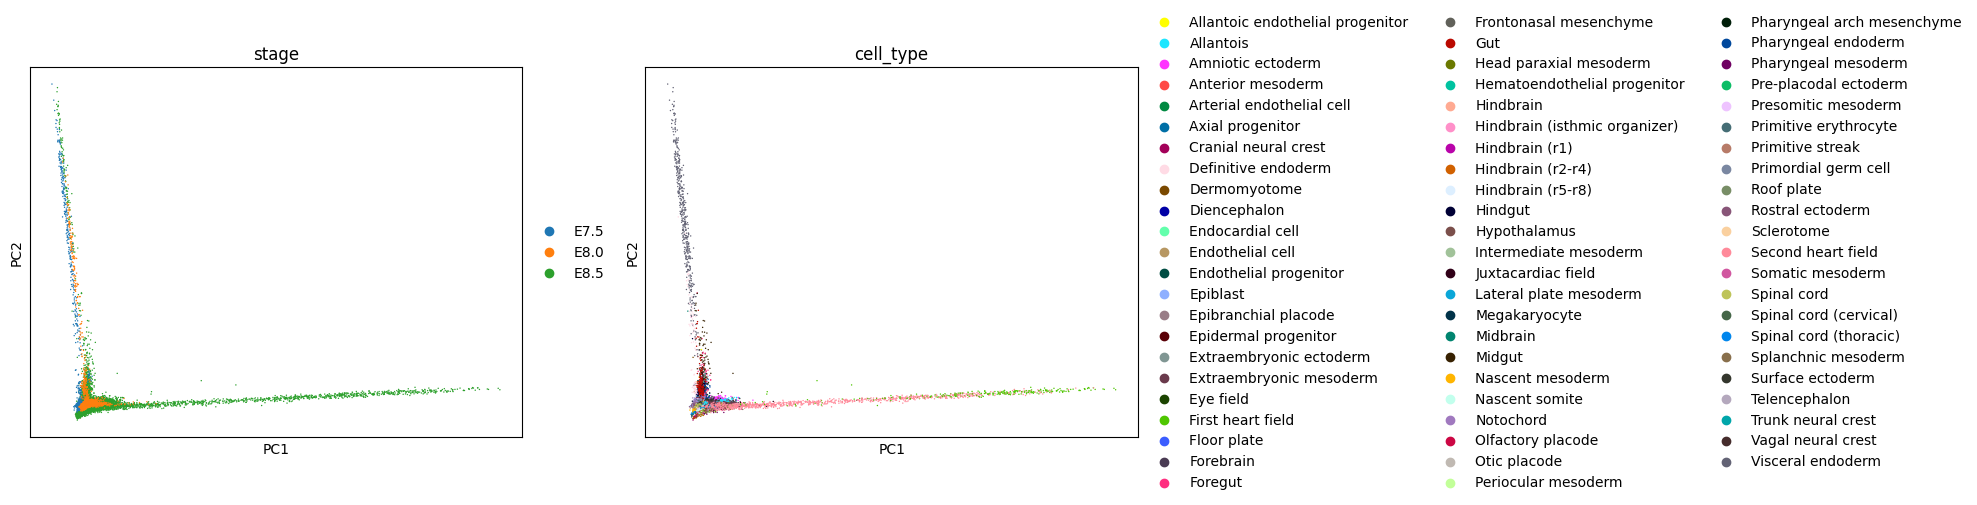

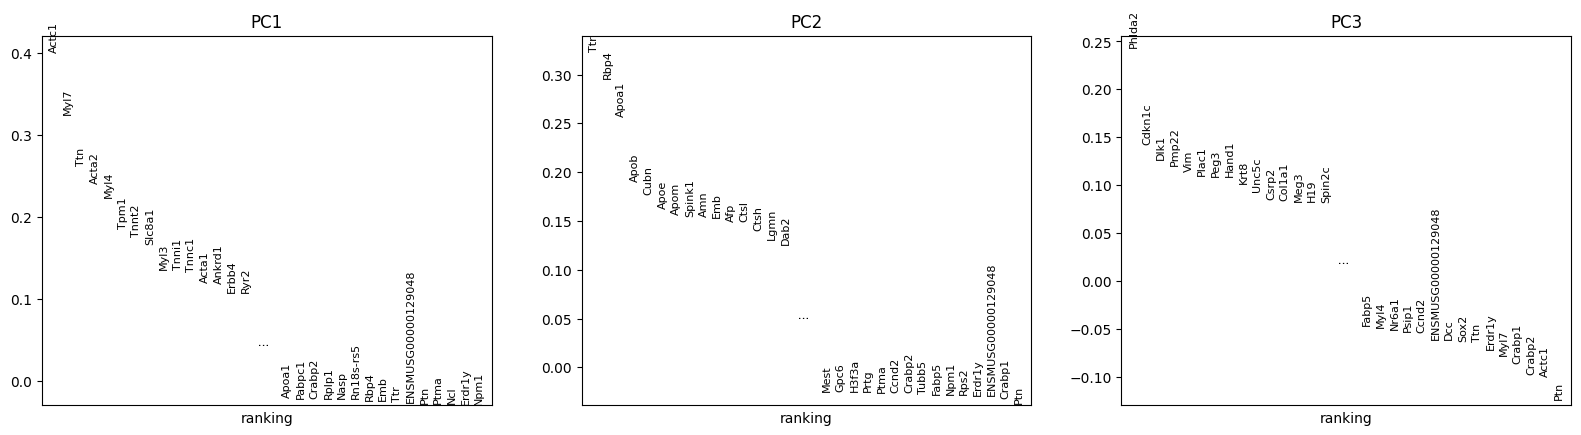

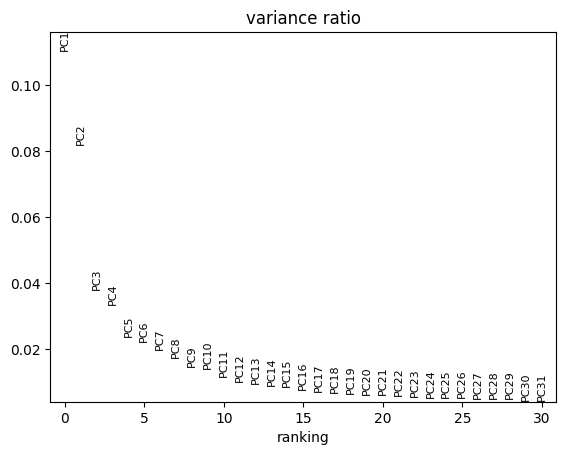

In [64]:
sc.pl.pca_overview(merged_tdata, color = ["stage", "cell_type"])

In [65]:
merged_tdata

TreeData object with n_obs × n_vars = 29232 × 78258
    obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'tree'
    var: 'gene_ids', 'mito', 'chromosome', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable'
    uns: 'hvg', 'pca', 'pearson_residuals_normalization', 'stage_colors', 'cell_type_colors'
    obsm: 'X_scvi', 'X_umap', 'characters', 'X_pca'
    varm: 'PCs'
    layers: 'raw'
    obst: 'E8.5-R1-C3', 'E7.5-R1-C1', 'E8.0-R1-C3', 'E8.5-R1-C1', 'E8.5-R1-C4', 'E8.5-R1-C2', 'E8.0-R1-C2', 'E8.0-R1-C1', 'E7.5-R1-C2'

#### Matrix Filtering and Datatype conversion

In [67]:
# Check what kind of characters are in this obsm
np.unique(merged_tdata.obsm['characters'])

array(['!', '*', '-', '1', '2', '3', '4', '5', '6', '7', '8'],
      dtype=object)

In [92]:
chars = merged_tdata.obsm["characters"]
print(chars.shape)         # should be (n_cells, n_target_sites)
#print(pd.DataFrame(chars).head(1))   # inspect values; expect integers or floats, not all zeros
print(pd.DataFrame(chars))  # each column should have >1 unique value if informative

(29232, 96)
                              intID1039-EMX1 intID1039-HEK3 intID1039-RNF2  \
E8.5-R1-T2-AGCCTGACATAAGCTA-1              *              *              *   
E8.5-R1-T2-GCAGCCATCTGTAAGT-1              *              *              *   
E8.5-R1-T2-TGATCCCCATGGTTAA-1              *              *              *   
E8.5-R1-T1-CGTACAGCAACGTGCA-1              *              *              *   
E8.5-R1-T2-ACGCGGTCAACCAACG-1              *              *              2   
...                                      ...            ...            ...   
E8.0-R1-T1-TGGGTGAAGTCAAGCC-1              -              -              -   
E8.0-R1-T1-TGGTCCTCACTCGGAA-1              -              -              -   
E8.0-R1-T1-TGTAGCGCAATCGAGT-1              -              -              -   
E8.0-R1-T1-TGTCGATGTGCAATCT-1              -              -              -   
E8.0-R1-T1-TGTCGTTTCGTGAGGA-1              -              -              -   

                              intID1068-EMX1 intID1

In [117]:
# Cleaning up the character matrix so it contains only string
chars = np.where(chars == '*', 0, chars) # no edit
chars = np.where(chars == '-', -1, chars) # not detected
chars = np.where(chars == "!", 999, chars) # Not editable, but is detected

# Note, those classifications were given by claude. Need to confirm with the author whether those are actually the correct labeling
chars = chars.astype(int)

In [118]:
merged_tdata.obsm['X_characters'] = chars.astype(int)

In [119]:
merged_tdata.obsm['X_characters'].dtype

dtype('int64')

In [120]:
np.unique(merged_tdata.obsm['X_characters'])

array([ -1,   0,   1,   2,   3,   4,   5,   6,   7,   8, 999])

#### Visualizing the distribution of no detections in every cell

#### Creating a column for numeric time


In [110]:
# need to make a time variable that is categorical with numeric based
merged_tdata.obs["time"] = pd.to_numeric(merged_tdata.obs['stage'].str[1:]).astype('category')

In [111]:
merged_tdata.obs['time'].unique()

[8.5, 7.5, 8.0]
Categories (3, float64): [7.5, 8.0, 8.5]

In [ ]:
lp = LineageProblem(merged_tdata)
lp = lp.prepare(
    time_key="time",
    joint_attr="X_pca",
    lineage_attr={"attr": "obsm", "key": "X_characters", "cost": "barcode_distance"},
    
)

INFO     Computing barcode distance                                                                                


ValueError: No shared indices.

#### Create Cost matrix between each time point (Using Gene Expression)

#### Create lp object and solve 